# Full pipeline: preprocessing, spike sorting, and bombcell quality control

This notebook walks through a complete Neuropixels analysis pipeline:

1. Load a SpikeGLX recording
2. Preprocess (highpass filter, remove bad channels, phase shift, common reference)
3. Run Kilosort4
4. Create a SortingAnalyzer and compute the metrics required by bombcell
5. Run bombcell to automatically label units as good, MUA, or noise


TODO: 
- time chunks
- GUI
- methods & supp. fig generation like in bombcell native 
- update docs to point to this file etc 

In [1]:
%matplotlib inline

In [2]:
import spikeinterface.full as si
import spikeinterface.curation as sc
import spikeinterface.widgets as sw

import matplotlib.pyplot as plt
from pathlib import Path
from pprint import pprint

/Users/jf5479/anaconda3/envs/spike_interface/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the recording

Point `spikeglx_folder` to your SpikeGLX recording folder. The AP stream is loaded automatically with probe geometry from the `.meta` file.

In [3]:
# Edit this path to point to your SpikeGLX recording folder
spikeglx_folder = Path("/Volumes/witten/Julie/bombcell_test_datasets/from_Scott_striatum_empty_units/TowersTask_g0/")
base_folder = spikeglx_folder  # Output folders will be created inside/alongside the recording

# Define output paths
preprocessed_folder = base_folder / "preprocessed"
kilosort_folder = base_folder / "kilosort4_output"
analyzer_folder = base_folder / "sorting_analyzer.zarr"

# Check if preprocessed recording already exists
preprocessed_exists = (preprocessed_folder / "si_folder.json").exists()
print(f"Preprocessed recording exists: {preprocessed_exists}")

Preprocessed recording exists: True


In [4]:
raw_rec = si.read_spikeglx(spikeglx_folder, stream_name="imec0.ap", load_sync_channel=False)
raw_rec


SpikeGLXRecordingExtractor: 384 channels - 30000.036975 Hz - 1 segments - 136,752,912 samples 
                            4,558.42s (1.27 hours) - int16 dtype - 97.81 GiB

In [5]:
# Verify probe geometry is loaded
raw_rec.get_probe().to_dataframe()

,x,y,contact_shapes,width,shank_ids,contact_ids
0,500.0,3600.0,square,12.0,2,s2e480
1,532.0,3600.0,square,12.0,2,s2e481
2,500.0,3615.0,square,12.0,2,s2e482
3,532.0,3615.0,square,12.0,2,s2e483
4,500.0,3630.0,square,12.0,2,s2e484
...,...,...,...,...,...,...
379,782.0,3555.0,square,12.0,3,s3e475
380,750.0,3570.0,square,12.0,3,s3e476
381,782.0,3570.0,square,12.0,3,s3e477
382,750.0,3585.0,square,12.0,3,s3e478


## 2. Preprocess the recording

We apply four standard preprocessing steps for Neuropixels data:

1. **Highpass filter** at 300 Hz to remove slow drifts
2. **Detect and remove bad channels** (dead or noisy channels)
3. **Phase shift** to correct for the inter-sample acquisition delays across channels
4. **Common median reference** to remove shared noise

All of these are **lazy** — no data is computed until we save or access traces.

In [6]:
# Step 1: Highpass filter
if not preprocessed_exists:
    rec_filtered = si.highpass_filter(raw_rec, freq_min=300.0)
else:
    print("Skipping highpass filter (preprocessed recording exists)")

Skipping highpass filter (preprocessed recording exists)


In [7]:
# Step 2: Detect and remove bad channels
import json
bad_channels_file = preprocessed_folder / "bad_channels.json"

if not preprocessed_exists:
    bad_channel_ids, channel_labels = si.detect_bad_channels(rec_filtered)
    print(f"Bad channels detected: {bad_channel_ids}")
    rec_clean = rec_filtered.remove_channels(bad_channel_ids)
    
    # Save bad channel info for future reference
    preprocessed_folder.mkdir(parents=True, exist_ok=True)
    bad_channel_info = {
        "bad_channel_ids": [str(ch) for ch in bad_channel_ids],
        "channel_labels": {str(k): v for k, v in zip(raw_rec.channel_ids, channel_labels)},
    }
    with open(bad_channels_file, "w") as f:
        json.dump(bad_channel_info, f, indent=2)
else:
    print("Skipping bad channel detection (preprocessed recording exists)")
    if bad_channels_file.exists():
        with open(bad_channels_file, "r") as f:
            bad_channel_info = json.load(f)
        print(f"Bad channels that were removed: {bad_channel_info['bad_channel_ids']}")

Skipping bad channel detection (preprocessed recording exists)


In [8]:
# Step 3: Phase shift correction (compensates inter-sample delays on Neuropixels)
if not preprocessed_exists:
    rec_shifted = si.phase_shift(rec_clean)
else:
    print("Skipping phase shift (preprocessed recording exists)")

Skipping phase shift (preprocessed recording exists)


In [9]:
# Step 4: Common median reference
if not preprocessed_exists:
    rec_cmr = si.common_reference(rec_shifted, reference="global", operator="median")
else:
    print("Skipping common reference (preprocessed recording exists)")

Skipping common reference (preprocessed recording exists)


### Visualize preprocessing

Compare traces at each stage to verify the preprocessing looks sensible.

In [10]:
# Only run visualization if we computed preprocessing (intermediate recordings exist)
if not preprocessed_exists:
    fig, axs = plt.subplots(ncols=3, figsize=(20, 10))
    si.plot_traces(rec_filtered, backend="matplotlib", clim=(-50, 50), ax=axs[0])
    si.plot_traces(rec_shifted, backend="matplotlib", clim=(-50, 50), ax=axs[1])
    si.plot_traces(rec_cmr, backend="matplotlib", clim=(-50, 50), ax=axs[2])
    for i, label in enumerate(("highpass", "phase_shift", "cmr")):
        axs[i].set_title(label)
    plt.show()
else:
    print("Skipping visualization (loaded from cache, intermediate recordings not available)")

Skipping visualization (loaded from cache, intermediate recordings not available)


### Save preprocessed recording to disk

Kilosort4 requires a binary file as input, so we save the preprocessed data. This also speeds up all downstream access. Adjust `n_jobs` to match your machine.

In [11]:
job_kwargs = dict(n_jobs=-1, chunk_duration="1s", progress_bar=True)

if preprocessed_exists:
    print(f"Loading existing preprocessed recording from {preprocessed_folder}")
    rec_preprocessed = si.load(preprocessed_folder)
else:
    print(f"Saving preprocessed recording to {preprocessed_folder}...")
    rec_preprocessed = rec_cmr.save(folder=preprocessed_folder, format="binary", **job_kwargs)

rec_preprocessed

Loading existing preprocessed recording from /Volumes/witten/Julie/bombcell_test_datasets/from_Scott_striatum_empty_units/TowersTask_g0/preprocessed


BinaryFolderRecording: 380 channels - 30000.036975 Hz - 1 segments - 136,752,912 samples 
                       4,558.42s (1.27 hours) - int16 dtype - 96.79 GiB

## 3. Run Kilosort4

Make sure Kilosort4 is installed: `pip install kilosort`

Since we already applied our own preprocessing (highpass, bad channel removal, phase shift, CMR), we tell Kilosort4 to **skip its internal preprocessing** and **disable its CAR**.

In [12]:
# Check default Kilosort4 parameters
pprint(si.get_default_sorter_params("kilosort4"))

{'Th_learned': 8,
 'Th_single_ch': 6,
 'Th_universal': 9,
 'acg_threshold': 0.2,
 'artifact_threshold': inf,
 'bad_channels': None,
 'batch_downsampling': 1,
 'batch_size': 60000,
 'binning_depth': 5,
 'ccg_threshold': 0.25,
 'chunk_duration': '1s',
 'clear_cache': False,
 'cluster_downsampling': 20,
 'cluster_init_seed': 5,
 'cluster_neighbors': 10,
 'delete_recording_dat': True,
 'dmin': None,
 'dminx': 32,
 'do_CAR': True,
 'do_correction': True,
 'drift_smoothing': [0.5, 0.5, 0.5],
 'duplicate_spike_ms': 0.25,
 'highpass_cutoff': 300,
 'invert_sign': False,
 'keep_good_only': False,
 'max_channel_distance': 32,
 'max_cluster_subset': 25000,
 'max_peels': 100,
 'max_threads_per_worker': 1,
 'min_template_size': 10,
 'mp_context': None,
 'n_jobs': 1,
 'n_pcs': 6,
 'n_templates': 6,
 'nblocks': 1,
 'nearest_chans': 10,
 'nearest_templates': 100,
 'nskip': 25,
 'nt': 61,
 'nt0min': None,
 'pool_engine': 'process',
 'position_limit': 100,
 'progress_bar': True,
 'save_extra_vars': False

In [13]:
if kilosort_folder.exists():
    print(f"Loading existing Kilosort4 output from {kilosort_folder}")
    # register_recording=False avoids errors when the original recording path
    # no longer exists (e.g. different mount point). The recording is linked
    # later when creating the SortingAnalyzer.
    sorting = si.read_sorter_folder(kilosort_folder, register_recording=False)
else:
    print("Running Kilosort4...")
    sorting = si.run_sorter(
        sorter_name="kilosort4",
        recording=rec_preprocessed,
        folder=kilosort_folder,
        remove_existing_folder=True,
        verbose=True,
        skip_kilosort_preprocessing=True,  # We already preprocessed
        do_CAR=False,                      # We already applied CMR
    )
print(f"Kilosort4 found {len(sorting.unit_ids)} units")

Loading existing Kilosort4 output from /Volumes/witten/Julie/bombcell_test_datasets/from_Scott_striatum_empty_units/TowersTask_g0/kilosort4_output
Kilosort4 found 634 units


## 4. Create SortingAnalyzer and compute bombcell requirements

The `SortingAnalyzer` links the sorting result back to the recording and lets us compute **extensions** (waveforms, templates, metrics, etc.).

bombcell needs two sets of metrics:
- **Quality metrics**: amplitude_median, snr, amplitude_cutoff, num_spikes, rp_contamination, presence_ratio, drift_ptp, and optionally isolation_distance and l_ratio (distance metrics)
- **Template metrics**: peak_to_trough_duration, num_positive/negative_peaks, waveform_baseline_flatness, exp_decay, and several peak ratio metrics

We compute these step by step below.

In [14]:
if analyzer_folder.exists():
    print(f"Loading existing SortingAnalyzer from {analyzer_folder}")
    analyzer = si.load_sorting_analyzer(analyzer_folder)
    # Re-attach recording if available (needed for computing new extensions)
    if not analyzer.has_recording():
        analyzer.set_temporary_recording(rec_preprocessed)
else:
    print("Creating new SortingAnalyzer...")
    analyzer = si.create_sorting_analyzer(
        sorting=sorting,
        recording=rec_preprocessed,
        sparse=True,
        format="zarr",
        folder=analyzer_folder,
        return_in_uV=True,
    )
analyzer

Loading existing SortingAnalyzer from /Volumes/witten/Julie/bombcell_test_datasets/from_Scott_striatum_empty_units/TowersTask_g0/sorting_analyzer.zarr


/Users/jf5479/Dropbox/Python/spikeinterface/src/spikeinterface/core/sortinganalyzer.py:2504: UserWarning: Found no run_info file for amplitude_scalings, extension should be re-computed.
  warnings.warn(f"Found no run_info file for {self.extension_name}, extension should be re-computed.")
/Users/jf5479/Dropbox/Python/spikeinterface/src/spikeinterface/core/sortinganalyzer.py:2586: UserWarning: Found no data for amplitude_scalings, extension should be re-computed.
  warnings.warn(f"Found no data for {self.extension_name}, extension should be re-computed.")


SortingAnalyzer: 380 channels - 634 units - 1 segments - zarr - sparse - has recording
Loaded 9 extensions: amplitude_scalings, noise_levels, random_spikes, spike_amplitudes, spike_locations, template_metrics, templates, unit_locations, waveforms

### 4a. Core extensions (waveforms and templates)

These are prerequisites for all metrics.

In [15]:
# Compute extensions if not already present
if not analyzer.has_extension("random_spikes"):
    print("Computing random_spikes...")
    analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=500)

if not analyzer.has_extension("waveforms"):
    print("Computing waveforms...")
    analyzer.compute("waveforms", ms_before=3.0, ms_after=3.0, **job_kwargs)

if not analyzer.has_extension("templates"):
    print("Computing templates...")
    analyzer.compute("templates", operators=["average", "median", "std"])

if not analyzer.has_extension("noise_levels"):
    print("Computing noise_levels...")
    analyzer.compute("noise_levels")

print("Core extensions ready.")

Core extensions ready.


### 4b. Quality metric prerequisites

These extensions are needed before computing quality metrics in section 5.

In [16]:
# Compute extensions required by quality metrics
if not analyzer.has_extension("spike_amplitudes"):
    print("Computing spike_amplitudes...")
    analyzer.compute("spike_amplitudes", **job_kwargs)

if not analyzer.has_extension("unit_locations"):
    print("Computing unit_locations...")
    analyzer.compute("unit_locations")

if not analyzer.has_extension("spike_locations"):
    print("Computing spike_locations...")
    analyzer.compute("spike_locations", **job_kwargs)

print("Quality metric prerequisites ready.")

Quality metric prerequisites ready.


### 4c. Template metrics

These feed into bombcell's noise and non-somatic classification (waveform shape features).

**Important**: set `include_multi_channel_metrics=True` so that `exp_decay` is computed — bombcell uses it for noise detection.

In [17]:
# Template metrics required by bombcell
required_metrics = ["peak_to_trough_duration", "waveform_baseline_flatness", "peak_after_to_trough_ratio"]

# Check if template_metrics exists and has all required metrics
needs_recompute = False
if analyzer.has_extension("template_metrics"):
    existing_metrics = analyzer.get_extension("template_metrics").get_data().columns.tolist()
    missing = [m for m in required_metrics if m not in existing_metrics]
    if missing:
        print(f"Template metrics missing bombcell-required metrics: {missing}")
        print("Deleting and recomputing template_metrics...")
        analyzer.delete_extension("template_metrics")
        needs_recompute = True
    else:
        print("Template metrics already computed with all required metrics.")
else:
    needs_recompute = True

if needs_recompute:
    print("Computing template_metrics...")
    analyzer.compute("template_metrics", include_multi_channel_metrics=True)

Template metrics already computed with all required metrics.


In [18]:
# Verify all metrics are available
all_metrics = analyzer.get_metrics_extension_data()
print(f"Computed {len(all_metrics.columns)} metrics for {len(all_metrics)} units")
all_metrics.head()

Computed 20 metrics for 634 units


,exp_decay,main_peak_to_trough_ratio,main_to_next_extremum_duration,num_negative_peaks,num_positive_peaks,peak_after_to_trough_ratio,peak_after_width,peak_before_to_peak_after_ratio,peak_before_to_trough_ratio,peak_before_width,peak_half_width,peak_to_trough_duration,recovery_slope,repolarization_slope,spread,trough_half_width,trough_width,velocity_above,velocity_below,waveform_baseline_flatness
0,0.004425,1.392740,0.000660,17,17,1.392740,0.000270,0.270524,0.376770,0.000418,0.000107,0.000660,-5029.909935,2.019898e+04,180.0,0.000313,0.000358,NaN,NaN,0.386022
1,0.012811,0.377906,0.000873,3,3,0.186354,0.000266,2.027895,0.377906,0.000386,0.000207,0.000873,-686.750984,9.961791e+04,105.0,0.000250,0.000280,NaN,NaN,0.061312
2,NaN,2.992547,0.000043,2,2,2.992547,0.000041,0.176081,0.526931,0.000031,0.000040,0.000043,-189802.193695,1.633915e+07,105.0,0.000023,0.000030,NaN,-1779.515853,0.005198
3,0.026104,0.423323,0.000047,1,2,0.423323,0.000030,0.784262,0.331996,0.000031,0.000027,0.000047,-55336.072910,2.274586e+07,180.0,0.000037,0.000043,2154.142708,NaN,0.003596
4,0.003476,1.734129,0.000047,4,3,0.304182,0.000032,5.700962,1.734129,0.000039,0.000033,0.000040,528.189817,5.067591e+05,135.0,0.000030,0.000035,-2866.005015,NaN,0.109412


## 5. Configure and compute quality metrics

Choose which metrics to compute and how. Toggle options control optional metrics (distance, drift).
The RPV method defaults to **sliding RP** (IBL/Steinmetz), which sweeps a range of refractory periods automatically.

**Note on drift metrics:**
- `drift_ptp` measures peak-to-peak drift in micrometers over the recording
- For **chronic recordings**, consider disabling or increasing the drift threshold
- For **acute recordings**, keep the drift threshold strict

**Note on distance metrics (isolation_distance, l_ratio):**
- Require PCA features — **optional**, off by default
- Best for **stable recordings** (drift artificially worsens these metrics)
- Default thresholds: `isolation_distance >= 20`, `l_ratio <= 0.3`

In [19]:
# Toggle options: which metrics to compute

# Distance metrics (isolation_distance, l_ratio)
# These depend on drift: more drift = artificially lower isolation and lower l_ratio.
# Best for stable recordings (e.g., chronic implants with minimal drift).
# For acute recordings or sessions with significant drift, leave OFF.
compute_distance_metrics = False

# Drift estimation (drift_ptp metric)
compute_drift = True

# Non-somatic detection (axonal/dendritic waveforms)
label_non_somatic = True

# Split non-somatic by quality: "non_soma_good" vs "non_soma_mua"
# If False, all get "non_soma" label
split_non_somatic_good_mua = False

# Valid time periods: compute quality metrics only on time chunks where
# false positive (RPV) and false negative (amplitude cutoff) rates are acceptable.
# The FP/FN thresholds are derived from the bombcell RPV and amplitude_cutoff thresholds.
# Requires amplitude_scalings extension and Numba.
use_valid_periods = False

print("Toggle options:")
print(f"  compute_distance_metrics = {compute_distance_metrics}")
print(f"  compute_drift = {compute_drift}")
print(f"  label_non_somatic = {label_non_somatic}")
print(f"  split_non_somatic_good_mua = {split_non_somatic_good_mua}")
print(f"  use_valid_periods = {use_valid_periods}")

Toggle options:
  compute_distance_metrics = False
  compute_drift = True
  label_non_somatic = True
  split_non_somatic_good_mua = False
  use_valid_periods = False


In [20]:
# Metric computation parameters

# RPV algorithm: "llobet" or "sliding_rp"
# - "llobet": Llobet & Wyngaard 2022, requires setting refractory_period_ms
# - "sliding_rp": IBL/Steinmetz (Roth et al.), sweeps a range of RP values automatically
rp_violation_method = "sliding_rp"

# Llobet parameters (only used if rp_violation_method = "llobet")
# Note: OG bombcell default tauR is 2 ms; SI default is 1 ms.
# OG bombcell supports sweeping a range (tauR_valuesMin/Max/Step) — in SI, set a single value.
# If you need to test multiple RP values, use "sliding_rp" which sweeps automatically.
refractory_period_ms = 2.0    # tauR: spikes closer than this are violations
censored_period_ms = 0.1      # exclude duplicate spike detections

# Sliding RP parameters (only used if rp_violation_method = "sliding_rp")
# Internally sweeps all RP values in [exclude_ref_period_below_ms, max_ref_period_ms].
# This is equivalent to OG bombcell's tauR_valuesMin/Max sweep.
exclude_ref_period_below_ms = 0.5  # min RP to consider (ms), like tauR_valuesMin
max_ref_period_ms = 10.0           # max RP to consider (ms), like tauR_valuesMax

# Presence ratio
presence_bin_duration_s = 60

# Drift
drift_interval_s = 60
drift_min_spikes = 100

# Distance metrics
n_pcs = 5                     # number of principal components for distance metrics

# Valid time periods parameters (only used if use_valid_periods = True)
# These control how time chunks are defined and which are kept.
# fp_threshold and fn_threshold are automatically derived from bombcell thresholds
# (rpv -> fp_threshold, amplitude_cutoff -> fn_threshold) unless overridden here.
valid_periods_params = {
    "refractory_period_ms": refractory_period_ms,
    "censored_period_ms": censored_period_ms,
    "period_mode": "absolute",              # "absolute" or "relative" (by spike count)
    "period_duration_s_absolute": 30.0,     # chunk duration in seconds (absolute mode)
    "period_target_num_spikes": 300,        # target spikes per chunk (relative mode)
    "minimum_valid_period_duration": 180,   # min duration (s) for a valid period to be kept
}

qm_params = {
    "presence_ratio": {"bin_duration_s": presence_bin_duration_s},
    "rp_violation": {"refractory_period_ms": refractory_period_ms, "censored_period_ms": censored_period_ms},
    "sliding_rp_violation": {
        "exclude_ref_period_below_ms": exclude_ref_period_below_ms,
        "max_ref_period_ms": max_ref_period_ms,
    },
    "drift": {"interval_s": drift_interval_s, "min_spikes_per_interval": drift_min_spikes},
}

# --- Quality metrics to compute ---
# These are the default metrics needed by bombcell.
# You can add any SI quality metric here — it will appear in the metrics DataFrame
# and can be used as a bombcell threshold (see section 6).
metric_names = [
    "amplitude_median", "snr", "amplitude_cutoff", "num_spikes",
    "presence_ratio", "firing_rate"
]

if rp_violation_method == "sliding_rp":
    metric_names.append("sliding_rp_violation")
else:  # llobet
    metric_names.append("rp_violation")

if compute_drift:
    metric_names.append("drift")

if compute_distance_metrics:
    metric_names.append("mahalanobis")  # produces isolation_distance and l_ratio columns
    if not analyzer.has_extension("principal_components"):
        print("Computing principal_components (required for distance metrics)...")
        analyzer.compute("principal_components", n_components=n_pcs, mode="by_channel_local", **job_kwargs)

# Compute amplitude_scalings if needed (required for valid_unit_periods)
if use_valid_periods and not analyzer.has_extension("amplitude_scalings"):
    print("Computing amplitude_scalings (required for valid_unit_periods)...")
    analyzer.compute("amplitude_scalings", **job_kwargs)

# To add more metrics, just append them here. For example:
# metric_names.append("silhouette")    # requires principal_components
# metric_names.append("d_prime")       # requires principal_components
# metric_names.append("nearest_neighbor")  # 3requires principal_components
# Then add a corresponding threshold in section 6.

print(f"Computing: {metric_names}")
analyzer.compute("quality_metrics", metric_names=metric_names,                                         
                    metric_params=qm_params, save=False, **job_kwargs)                                   
#analyzer.save_as(format="zarr", folder="/Users/jf5479/analyzer.zarr") 

Computing: ['amplitude_median', 'snr', 'amplitude_cutoff', 'num_spikes', 'presence_ratio', 'firing_rate', 'sliding_rp_violation', 'drift']


/Users/jf5479/Dropbox/Python/spikeinterface/src/spikeinterface/metrics/quality/misc_metrics.py:1042: UserWarning: Amplitude cutoff set to NaN for units [np.int64(27), np.int64(65), np.int64(118), np.int64(133), np.int64(134), np.int64(135), np.int64(151), np.int64(152), np.int64(170), np.int64(208), np.int64(210), np.int64(213), np.int64(321), np.int64(477), np.int64(503), np.int64(550), np.int64(574), np.int64(575)]: too few spikes (< 500).
  warnings.warn(
/Users/jf5479/Dropbox/Python/spikeinterface/src/spikeinterface/metrics/quality/misc_metrics.py:1339: UserWarning: Drift metrics could not be computed for units [np.int64(2), np.int64(3), np.int64(27), np.int64(35), np.int64(48), np.int64(49), np.int64(65), np.int64(76), np.int64(77), np.int64(118), np.int64(133), np.int64(134), np.int64(135), np.int64(137), np.int64(138), np.int64(144), np.int64(151), np.int64(152), np.int64(158), np.int64(170), np.int64(201), np.int64(208), np.int64(210), np.int64(213), np.int64(228), np.int64(229

## 6. Run bombcell

bombcell applies thresholds to classify units into **noise**, **mua**, **good**, and optionally **non-somatic**.

### Customizing thresholds

The thresholds dict has three sections — `"noise"`, `"mua"`, and `"non-somatic"` — each containing
metric entries of the form `{"greater": val, "less": val}`. Use `None` to disable one side.

**You can add any metric** that exists in the analyzer's metrics DataFrame to any section:
- **noise/mua**: units failing any threshold in the section get that label. Custom metrics work
  exactly like built-in ones.
- **non-somatic**: custom metrics are OR'd with the built-in waveform shape logic as standalone
  conditions (i.e., failing the custom threshold alone is enough to label a unit as non-somatic).

Custom metrics automatically appear in the histogram and upset plots.

In [21]:
# Get default thresholds and adjust as needed
thresholds = sc.bombcell_get_default_thresholds()

# --- Adjust existing thresholds ---

# RPV threshold (applies to whichever RPV method you computed: sliding_rp or llobet)
thresholds["mua"]["rpv"]["less"] = 0.1

# Presence ratio — lower for bursty or sparse-firing neurons
thresholds["mua"]["presence_ratio"]["greater"] = 0.7

# Distance metric thresholds (applied automatically when computed, skipped otherwise)
# thresholds["mua"]["isolation_distance"]["greater"] = 20   # default: 20
# thresholds["mua"]["l_ratio"]["less"] = 0.3                # default: 0.3

# Disable a threshold without removing it (set both sides to None):
# thresholds["mua"]["drift_ptp"] = {"greater": None, "less": None}

# --- Add custom metrics to any section ---
# Any column in the analyzer's metrics DataFrame can be used as a threshold.
# If the metric hasn't been computed, it is skipped with a warning.

# Example: require minimum firing rate for MUA classification
# thresholds["mua"]["firing_rate"] = {"greater": 0.1, "less": None}

# Example: flag units with extreme half-width as noise
# thresholds["noise"]["half_width"] = {"greater": 0.05e-3, "less": 0.6e-3}

# Example: use absolute value (like amplitude_median does by default)
# thresholds["mua"]["my_metric"] = {"greater": 5, "less": None, "abs": True}

# Example: add another distance metric (e.g. silhouette score) as MUA threshold.
# First compute it: metric_names.append("silhouette") in the quality metrics cell,
# then add the threshold here:
# thresholds["mua"]["silhouette"] = {"greater": 0.4, "less": None}

# Example: add a custom non-somatic detector.
# Custom metrics in "non-somatic" are OR'd with the built-in waveform shape logic,
# so failing this threshold alone is enough to label a unit as non-somatic:
# thresholds["non-somatic"]["velocity"] = {"greater": 2.0, "less": None}

pprint(thresholds)

{'mua': {'amplitude_cutoff': {'greater': None, 'less': 0.2},
         'amplitude_median': {'abs': True, 'greater': 30, 'less': None},
         'drift_ptp': {'greater': None, 'less': 100},
         'isolation_distance': {'greater': 20, 'less': None},
         'l_ratio': {'greater': None, 'less': 0.3},
         'num_spikes': {'greater': 300, 'less': None},
         'presence_ratio': {'greater': 0.7, 'less': None},
         'rpv': {'greater': None, 'less': 0.1},
         'snr': {'greater': 5, 'less': None}},
 'noise': {'exp_decay': {'greater': 0.01, 'less': 0.1},
           'num_negative_peaks': {'greater': None, 'less': 1},
           'num_positive_peaks': {'greater': None, 'less': 2},
           'peak_after_to_trough_ratio': {'greater': None, 'less': 0.8},
           'peak_to_trough_duration': {'greater': 0.0001, 'less': 0.00115},
           'waveform_baseline_flatness': {'greater': None, 'less': 0.5}},
 'non-somatic': {'main_peak_to_trough_ratio': {'greater': None, 'less': 0.8},
      

In [22]:
bombcell_labels = sc.bombcell_label_units(
    sorting_analyzer=analyzer,
    thresholds=thresholds,
    label_non_somatic=label_non_somatic,
    split_non_somatic_good_mua=split_non_somatic_good_mua,
    use_valid_periods=use_valid_periods,
    valid_periods_params=valid_periods_params if use_valid_periods else None,
    **job_kwargs,
)

print(f"Labeled {len(bombcell_labels)} units")
print(bombcell_labels["bombcell_label"].value_counts())

Labeled 634 units
bombcell_label
noise       389
mua         164
non_soma     42
good         39
Name: count, dtype: int64


/Users/jf5479/Dropbox/Python/spikeinterface/src/spikeinterface/curation/bombcell_curation.py:280: UserWarning: Bombcell thresholds reference metrics not found in the metrics DataFrame (section 'mua'): ['isolation_distance', 'l_ratio']. These will be skipped. Compute them first if you want them included in the labeling.
  warnings.warn(


## 7. Parameter tuning by recording type

**Chronic recordings**
- Distance metrics work well (stable recordings = reliable isolation_distance/l_ratio)
- Set `compute_distance_metrics = True`
- Increase or disable drift threshold

**Acute recordings**
- Distance metrics unreliable (drift artificially lowers isolation_distance/l_ratio)
- Keep `compute_distance_metrics = False` (default)
- Keep drift threshold strict

**Cerebellum**
- Purkinje cells: shorter peak-to-trough duration
- Complex spikes may trigger noise detection; relax `num_positive_peaks`

**Striatum**
- MSNs: lower spike count and presence ratio thresholds

### Visualize results

Text(0.5, 0.98, 'bombcell unit labeling')

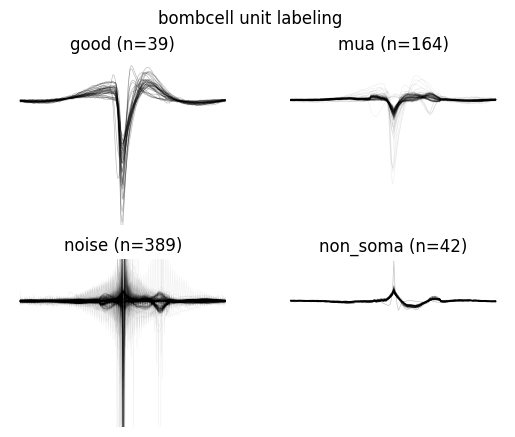

In [25]:
# Unit waveforms colored by bombcell label
w = sw.plot_unit_labels(analyzer, bombcell_labels["bombcell_label"], ylims=(-300, 100))
w.figure.suptitle("bombcell unit labeling")

In [24]:
# Template and mean raw waveform with detected peaks and troughs
# Shows peak_before (green), trough (blue), and peak_after (orange) on the peak channel
# Main features are highlighted with a red edge
_ = sw.plot_template_peak_trough(
    analyzer,
    unit_ids=analyzer.unit_ids[:8],  # plot first 8 units; set to None for all
    n_channels_around=2,  # show 2 channels above and below peak channel (0 = peak only)
    unit_labels=bombcell_labels["bombcell_label"],
    figsize=(20, 12),
)

AttributeError: module 'spikeinterface.widgets' has no attribute 'plot_template_peak_trough'

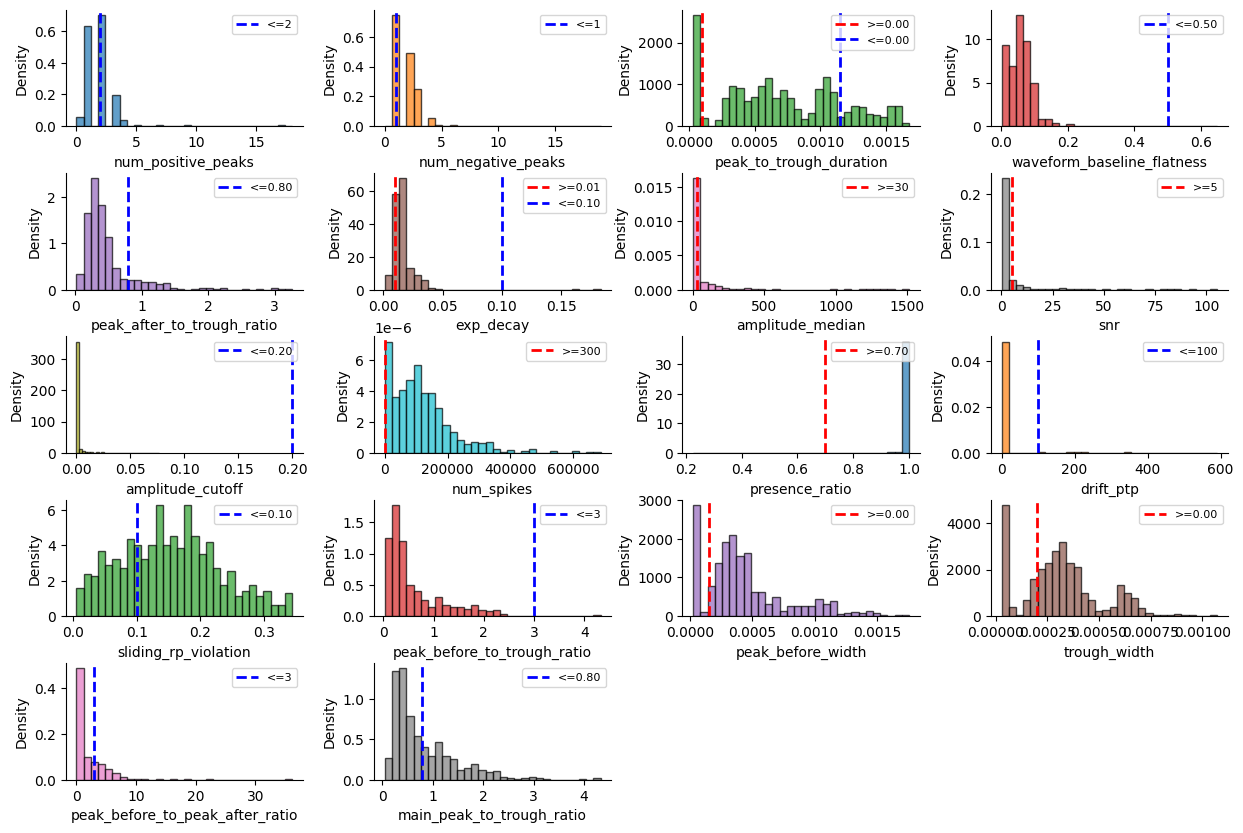

In [26]:
# Metric distributions with threshold lines
_ = sw.plot_metric_histograms(analyzer, thresholds, figsize=(15, 10))

In [ ]:
# Upset plot: which metric combinations caused each label
# You can also include "non_soma" in unit_labels_to_plot to see non-somatic metric patterns
_ = sw.plot_bombcell_labels_upset(
    analyzer,
    unit_labels=bombcell_labels["bombcell_label"],
    thresholds=thresholds,
    unit_labels_to_plot=["noise", "mua"],
)